подключение гугл диска с кубом

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install segyio

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 6.5 MB/s eta 0:00:00


загрузка трех фрагментов: первые и послдение 700 трасс, и 400 трасс посередине (попало на границу профилей куба видимо (вертикальная линия))

In [6]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/drive/My Drive/cw_data/TrainingData_Image.segy'

with segyio.open(file_path, "r", ignore_geometry=True) as segyfile:
    n_traces_total = len(segyfile.trace)
    n_samples = segyfile.trace[0].size

fragments = {
    'Начало куба (первые 700 трасс)': (0, 700),
    'Середина куба (400 трасс)': (n_traces_total // 2 - 200, n_traces_total // 2 + 200),
    'Конец куба (последние 700 трасс)': (n_traces_total - 700, n_traces_total)
}

seismic_data = {}

with segyio.open(file_path, "r", ignore_geometry=True) as segyfile:
    for name, (start, end) in fragments.items():
        n_traces = end - start
        data = np.zeros((n_traces, n_samples), dtype=np.float32)
        for i, idx in enumerate(range(start, end)):
            data[i, :] = segyfile.trace[idx]
        seismic_data[name] = data

Функции когерентности


In [7]:
from scipy.ndimage import generic_filter

def moving_window(data, window, func):
    total_traces = window[0] * window[1]
    window_samples = window[2]

    def wrapped(region):
        region_2d = region.reshape(total_traces, window_samples)
        return func(region_2d)

    return generic_filter(data, wrapped, size=window, mode='reflect')


def marfurt_semblance(region):
    region = region.reshape(-1, region.shape[-1])
    ntraces, nsamples = region.shape

    square_of_sums = np.sum(region, axis=0)**2
    sum_of_squares = np.sum(region**2, axis=0)
    sembl = square_of_sums.sum() / (sum_of_squares.sum() + 1e-10)

    return sembl / ntraces


def gerstenkorn_eigenstructure(region):
    region = region.reshape(-1, region.shape[-1])
    cov = region.dot(region.T)
    vals = np.linalg.eigvalsh(cov)
    return vals.max() / (vals.sum() + 1e-10)

вычисление когерентности для всех фрагментов

In [8]:
window_traces = 5
window_time = 11
window = (window_traces, 1, window_time)

marfurt_results = {}
eigen_results = {}

for name, data in seismic_data.items():
    n_traces = data.shape[0]
    data_3d = data.reshape(n_traces, 1, n_samples)

    marfurt_results[name] = moving_window(data_3d, window, marfurt_semblance)
    eigen_results[name] = moving_window(data_3d, window, gerstenkorn_eigenstructure)

визуализация трех фрагментов

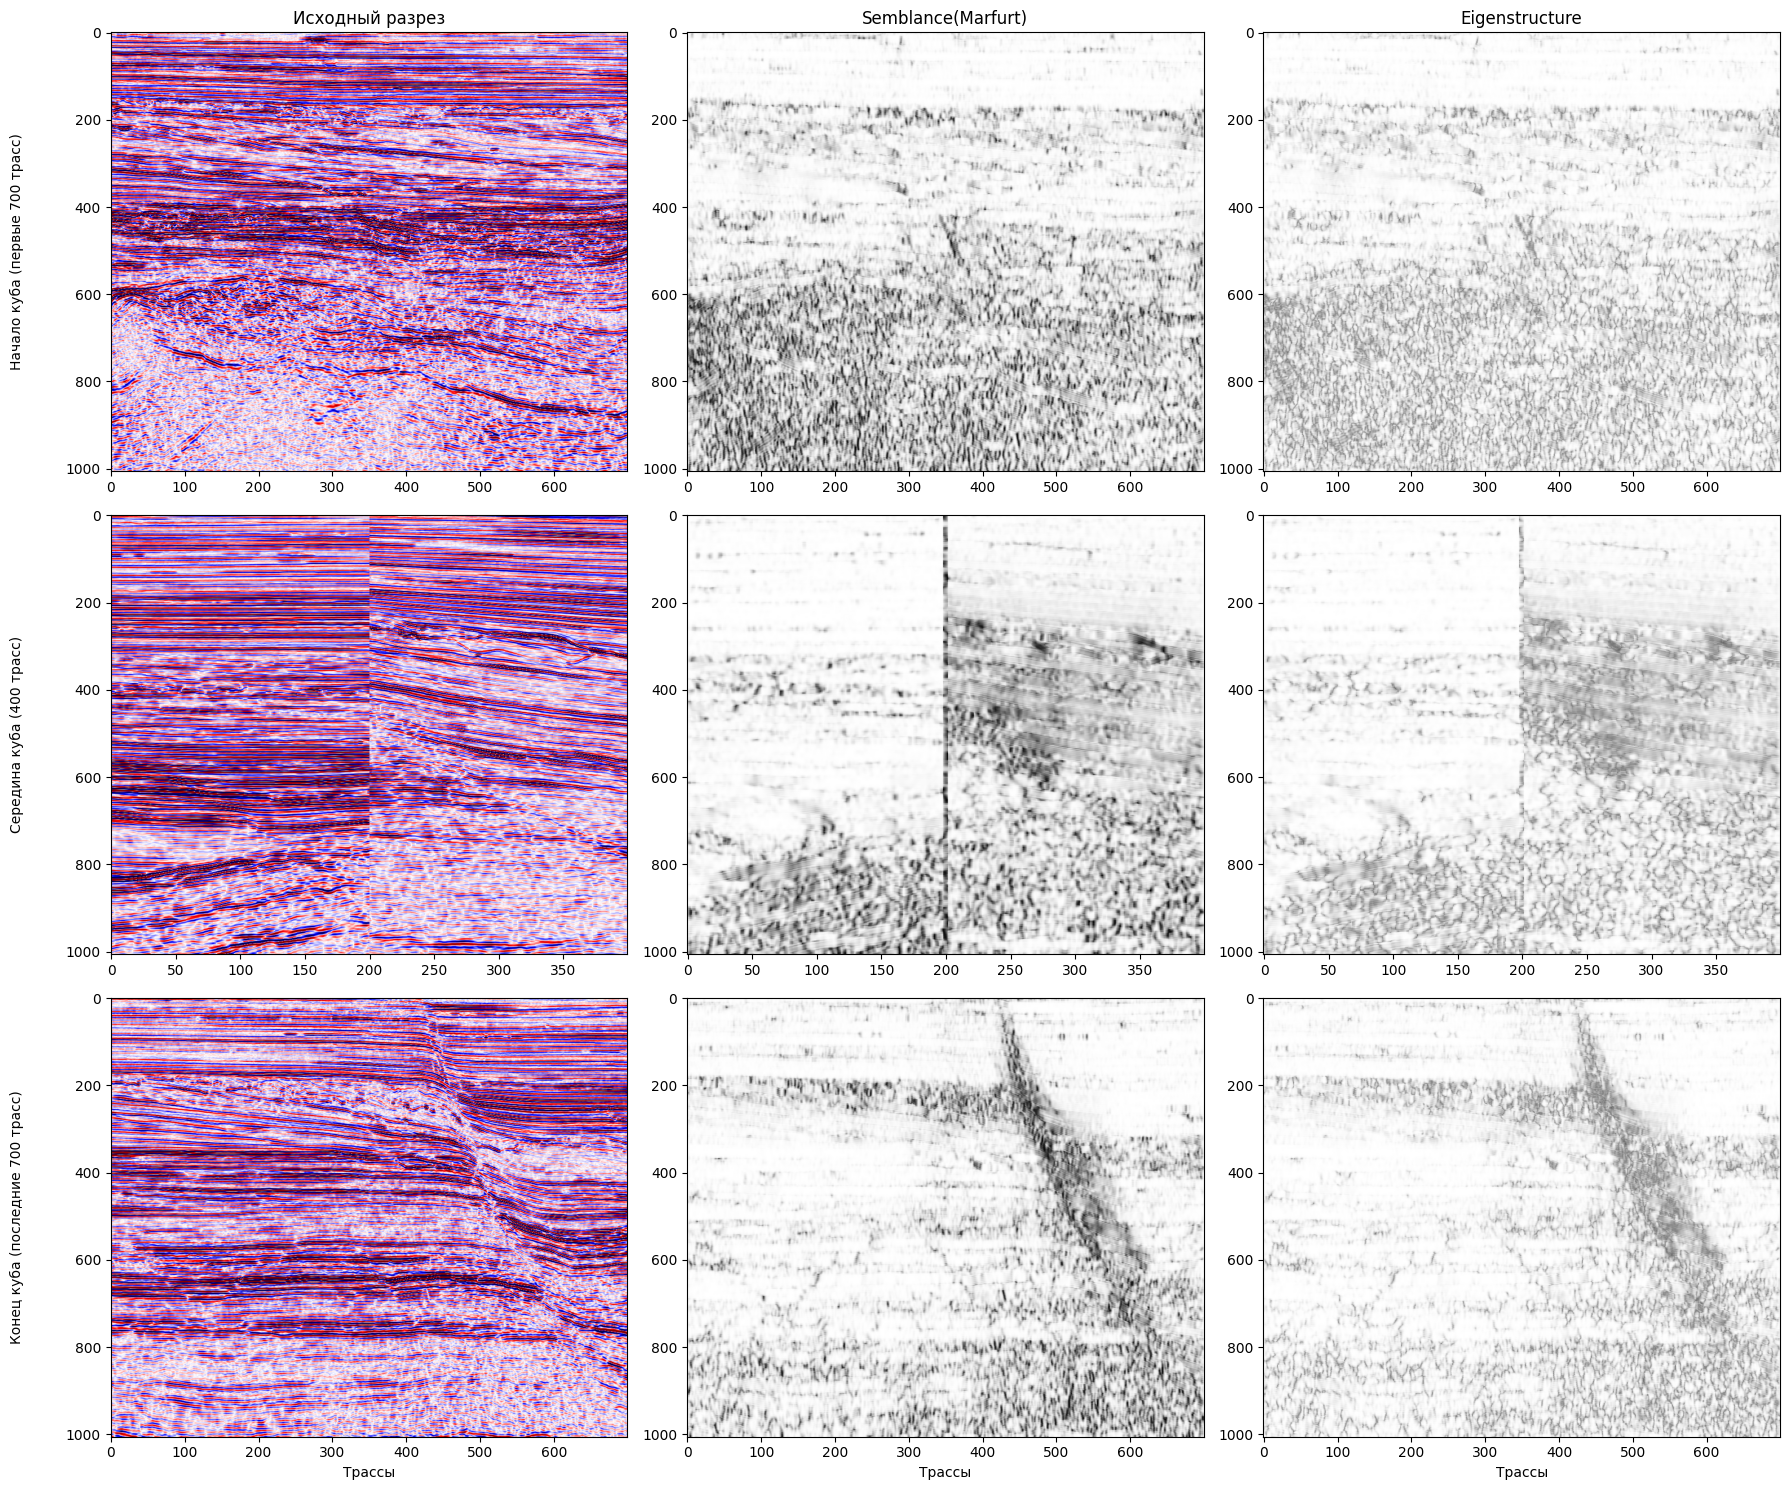

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row, (name, data) in enumerate(seismic_data.items()):
    # Исходный разрез
    vmax = np.percentile(np.abs(data), 95)
    axes[row, 0].imshow(data.T, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax)
    axes[row, 0].set_ylabel('Время')
    if row == 2:
        axes[row, 0].set_xlabel('Трассы')

    # Marfurt
    marf = marfurt_results[name]
    im1 = axes[row, 1].imshow(marf[:, 0, :].T, aspect='auto', cmap='gray', vmin=0, vmax=1)
    if row == 2:
        axes[row, 1].set_xlabel('Трассы')

    # Eigenstructure C3
    eigen = eigen_results[name]
    im2 = axes[row, 2].imshow(eigen[:, 0, :].T, aspect='auto', cmap='gray', vmin=0, vmax=1)
    if row == 2:
        axes[row, 2].set_xlabel('Трассы')

# Заголовки столбцов
axes[0, 0].set_title('Исходный разрез')
axes[0, 1].set_title('Semblance(Marfurt)')
axes[0, 2].set_title('Eigenstructure')

# Заголовки строк
for row, name in enumerate(seismic_data.keys()):
    axes[row, 0].set_ylabel(name, rotation=90, size=10, labelpad=30)

plt.tight_layout()
plt.show()